In [2]:
%pip uninstall -y -q \
  opentelemetry-api \
  opentelemetry-sdk \
  opentelemetry-semantic-conventions \
  opentelemetry-instrumentation \
  opentelemetry-instrumentation-asgi \
  opentelemetry-instrumentation-fastapi \
  opentelemetry-util-http \
  opentelemetry-exporter-otlp \
  opentelemetry-exporter-otlp-proto-common \
  opentelemetry-exporter-otlp-proto-grpc \
  opentelemetry-exporter-otlp-proto-http \
  chromadb \
  langchain-chroma \
  torchcodec

In [3]:
%pip install -q -U --force-reinstall \
  "opentelemetry-api==1.41.1" \
  "opentelemetry-sdk==1.41.1" \
  "opentelemetry-semantic-conventions==0.62b1" \
  langchain-chroma \
  langchain-huggingface \
  langchain-community \
  langchain-litellm \
  sentence-transformers \
  rank_bm25 \
  lxml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

print("ok")

ok


In [2]:
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")
LLM_MODEL = "mistral/mistral-small-latest"

In [3]:
from collections import Counter
import json
import matplotlib.pyplot as plt

candidates = []
with open('vacancy_conditioned_candidates.jsonl', 'r') as f:
    for line in f:
        candidates.append(json.loads(line))

In [14]:
candidates[10]

{'id': 11,
 'source_vacancy_id': 'vacancy_000015',
 'type': 'cv',
 'word_count': 1028,
 'text': 'John Doe\nEmail: johndoe@example.com\nVictoria, Australia\nLinkedIn: linkedin.com/in/johndoe\n\nObjective\nPassionate about empowering sales teams, I am seeking a senior sales enablement position where my extensive experience in B2B SaaS and cybersecurity can drive regional success.\n\nSummary\n- Over 6 years of experience in sales enablement and training for B2B SaaS companies\n- Expertise in sales methodologies such as MEDDPICC, Command of the Message\n- Proven track record of delivering high-impact enablement programs\n- Data-driven approach to identify and bridge performance gaps\n\nProfessional Experience\nSales Enablement Specialist\nABC Cybersecurity Solutions\nVictoria, Australia | March 2018 - Present\n- Design and implement tailored enablement programs for APAC sales teams\n- Act as a trusted advisor to sales leadership, aligning global strategies with regional needs\n- Successful

In [5]:
vacancies = []
with open('vacancies_safe_ml_dataset_nozip.jsonl', 'r') as f:
    for line in f:
        vacancies.append(json.loads(line))

In [15]:
vacancies[14]

{'dataset_id': 'vacancy_000015',
 'title': 'Senior Sales Enablement Business Partner (Cybersecurity)',
 'original_title': 'Senior Sales Enablement Business Partner, APAC',
 'vacancy_score': 9,
 'work_format': ['hybrid'],
 'work_type': 'fulltime',
 'english_level': 'c1',
 'employee_type': ['employment'],
 'company_type': 'product_company',
 'vacancy_language': 'en',
 'remote_type': None,
 'remote_restrictions': [],
 'excluded_locations': [],
 'salary': {'min': 180000,
  'max': 270000,
  'currency': 'AUD',
  'salary_in_usd': 145161},
 'tags': ['salesforce',
  'cybersecurity',
  'sales enablement',
  'apac',
  'b2b saas',
  'meddpicc',
  'gong',
  'seismic'],
 'grades': ['senior'],
 'specializations': ['sales'],
 'regions': ['australia'],
 'relocation_regions': [],
 'cities': ['victoria'],
 'company_domains': ['cybersecurity', 'saas'],
 'title_aliases': ['старший партнер по развитию продаж',
  'senior sales enablement manager'],
 'text_sanitized': '<h2>Senior Sales Enablement Business Par

In [16]:
vacancies[4]['specializations'][0]

'backend_dev'

In [17]:
def plot_vacancies_stats(name):
    specialization_counts = Counter(
        spec
        for vacancy in vacancies
        for spec in vacancy.get(name, [])
    )

    print(len(specialization_counts))  # number of different specializations
    print(specialization_counts)       # frequency of each one
    # assuming your Counter is named specialization_counts
    top_20 = specialization_counts.most_common(20)

    labels = [item[0] for item in top_20]
    values = [item[1] for item in top_20]

    plt.figure(figsize=(8, 6))
    plt.barh(labels, values)
    plt.xlabel("Number of vacancies")
    plt.ylabel(name)
    plt.title(f"Top 20 {name}")

    # Put the biggest one at the top
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

51
Counter({'marketing': 450, 'backend_dev': 376, 'sales': 303, 'finance': 237, 'content_creation': 225, 'qa_testing': 221, 'product_management': 215, 'project_management': 211, 'erp_dev': 205, 'graphic_design': 204, 'ai_engineering': 203, 'game_art': 203, 'game_design': 203, 'devops': 202, 'video_production': 201, 'fullstack_dev': 201, 'business_analytics': 201, 'uiux_design': 201, 'motion_design': 201, 'system_analytics': 201, 'engineering_management': 200, 'frontend_dev': 200, 'level_design': 200, 'cybersecurity': 199, 'architecture': 199, 'delivery_management': 199, 'hr_recruiting': 199, 'embedded_iot_dev': 199, 'mobile_development': 199, 'hr_bp': 199, 'customer_support': 198, 'game_producer': 198, 'data_analytics': 198, 'data_science_ml': 198, 'system_engineering': 198, 'program_management': 198, 'management': 198, 'product_design': 198, 'education': 198, 'pr_communications': 198, 'hr_operations': 198, 'game_development': 198, 'web_dev': 198, 'engineering': 120, 'logistics_supply_

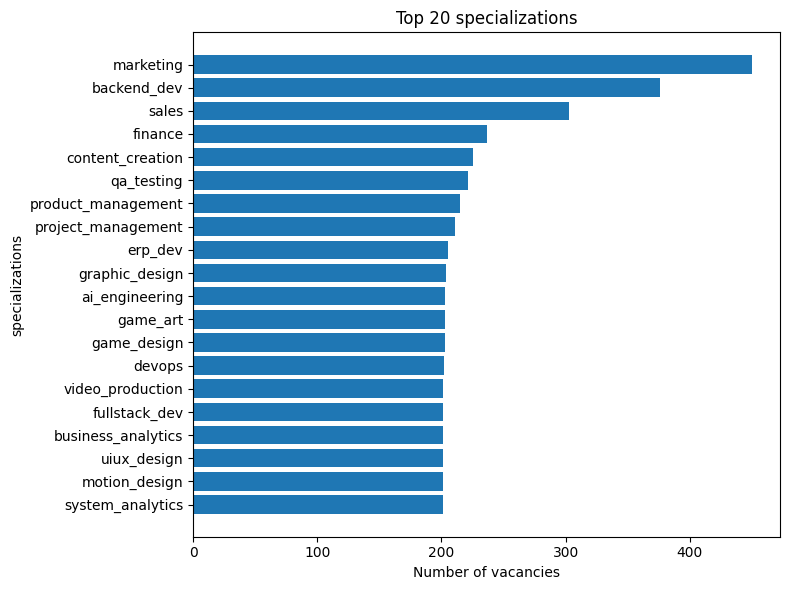

In [18]:
plot_vacancies_stats('specializations')

9
Counter({'senior': 3282, 'middle': 2759, 'lead': 960, 'junior': 703, 'trainee': 579, 'director': 442, 'head': 258, 'c_level': 150, 'principal': 9})


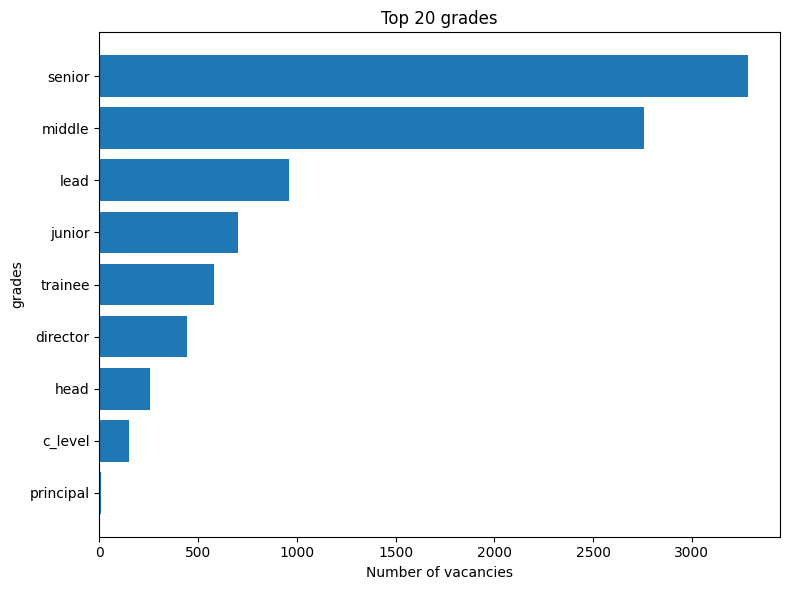

In [19]:
plot_vacancies_stats('grades')

140
Counter({'russia': 2515, 'united_states': 2345, 'united_kingdom': 650, 'canada': 345, 'poland': 296, 'germany': 246, 'spain': 189, 'netherlands': 187, 'mexico': 171, 'cyprus': 170, 'belarus': 135, 'kazakhstan': 134, 'ukraine': 117, 'serbia': 111, 'portugal': 104, 'united_arab_emirates': 101, 'australia': 100, 'armenia': 96, 'france': 95, 'romania': 89, 'brazil': 89, 'singapore': 83, 'israel': 83, 'china': 78, 'italy': 77, 'philippines': 73, 'sweden': 70, 'colombia': 68, 'ireland': 65, 'malaysia': 57, 'switzerland': 56, 'georgia': 54, 'europe': 53, 'argentina': 48, 'uzbekistan': 47, 'vietnam': 44, 'india': 43, 'bulgaria': 40, 'belgium': 37, 'austria': 37, 'lithuania': 35, 'south_africa': 34, 'czech_republic': 33, 'finland': 32, 'japan': 30, 'hungary': 29, 'costa_rica': 26, 'turkey': 26, 'saudi_arabia': 24, 'new_zealand': 23, 'chile': 23, 'moldova': 22, 'latvia': 21, 'denmark': 21, 'malta': 19, 'south_korea': 18, 'estonia': 18, 'indonesia': 18, 'egypt': 17, 'greece': 17, 'thailand': 

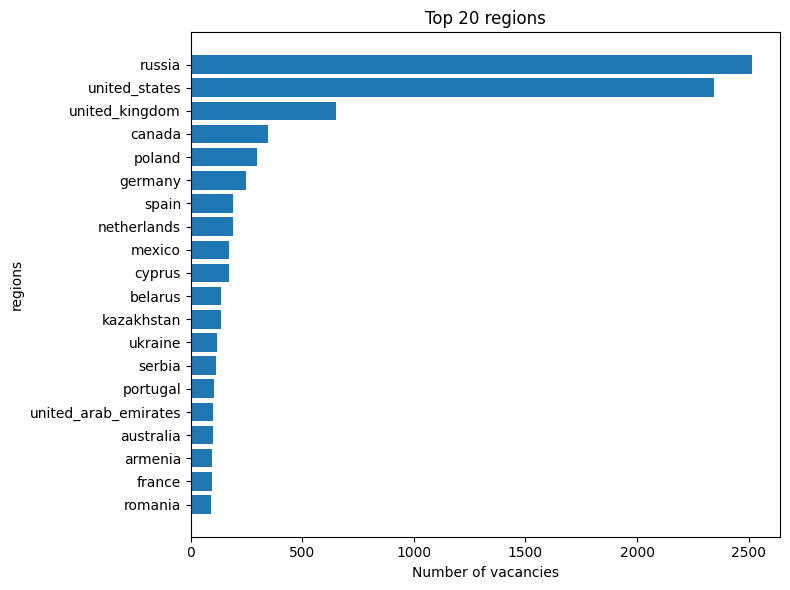

In [20]:
plot_vacancies_stats('regions')

In [24]:
import json
from pathlib import Path
from bs4 import BeautifulSoup

from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma


CANDIDATES_PATH = Path("vacancy_conditioned_candidates.jsonl")
VACANCIES_PATH = Path("vacancies_safe_ml_dataset_nozip.jsonl")

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
TOP_K = 100

In [25]:
def load_jsonl(path: Path) -> list[dict]:
    items = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            items.append(json.loads(line))
    return items


candidates = load_jsonl(CANDIDATES_PATH)
vacancies = load_jsonl(VACANCIES_PATH) # [:1000]

print(f"Loaded {len(candidates)} candidates")
print(f"Loaded {len(vacancies)} vacancies")

Loaded 100 candidates
Loaded 10000 vacancies


In [26]:
vacancies[0]

{'dataset_id': 'vacancy_000001',
 'title': 'T Hub - AI & Digitalization Product Owner (AI)',
 'original_title': 'T Hub - AI & Digitalization Product Owner',
 'vacancy_score': 7,
 'work_format': ['hybrid'],
 'work_type': 'fulltime',
 'english_level': 'c1',
 'employee_type': ['employment'],
 'company_type': 'corporation',
 'vacancy_language': 'en',
 'remote_type': 'europe',
 'remote_restrictions': ['poland'],
 'excluded_locations': [],
 'salary': None,
 'tags': ['ai',
  'ml',
  'product management',
  'process optimization',
  'stakeholder management',
  'kpis',
  'digital transformation',
  'workshops'],
 'grades': ['senior'],
 'specializations': ['product_management'],
 'regions': ['poland'],
 'relocation_regions': [],
 'cities': ['warsaw'],
 'company_domains': ['ai'],
 'title_aliases': ['продукт-оунер по ai и цифровизации',
  'ai product manager',
  't hub - artificial intelligence & digitalization product owner (artificial intelligence)'],
 'text_sanitized': '<h2>T Hub - AI &amp; Dig

In [27]:
def clean_html(html: str | None) -> str:
    if not html:
        return ""

    soup = BeautifulSoup(html, "html.parser")
    return soup.get_text(separator=" ", strip=True)


def join_list(value) -> str:
    if not value:
        return ""
    if isinstance(value, list):
        return ", ".join(str(x) for x in value)
    return str(value)


def vacancy_to_text(vacancy: dict) -> str:
    parts = [
        f"Title: {vacancy.get('title', '')}",
        f"Original title: {vacancy.get('original_title', '')}",
        f"Work format: {join_list(vacancy.get('work_format'))}",
        f"Work type: {vacancy.get('work_type', '')}",
        f"English level: {vacancy.get('english_level', '')}",
        f"Employee type: {join_list(vacancy.get('employee_type'))}",
        f"Company type: {vacancy.get('company_type', '')}",
        f"Tags: {join_list(vacancy.get('tags'))}",
        f"Grades: {join_list(vacancy.get('grades'))}",
        f"Specializations: {join_list(vacancy.get('specializations'))}",
        f"Regions: {join_list(vacancy.get('regions'))}",
        f"Cities: {join_list(vacancy.get('cities'))}",
        f"Company domains: {join_list(vacancy.get('company_domains'))}",
        f"Title aliases: {join_list(vacancy.get('title_aliases'))}",
        f"Description: {clean_html(vacancy.get('tldr_sanitized') or vacancy.get('text_sanitized'))}",
    ]

    return "\n".join(part for part in parts if part.strip())

In [28]:
def vacancy_to_metadata(vacancy: dict) -> dict:
    return {
        "dataset_id": str(vacancy.get("dataset_id", "")),
        "title": str(vacancy.get("title", "")),
        "work_type": str(vacancy.get("work_type") or ""),
        "work_format": join_list(vacancy.get("work_format")),
        "english_level": str(vacancy.get("english_level") or ""),
        "employee_type": join_list(vacancy.get("employee_type")),
        "regions": join_list(vacancy.get("regions")),
        "cities": join_list(vacancy.get("cities")),
        "specializations": join_list(vacancy.get("specializations")),
        "tags": join_list(vacancy.get("tags")),
        "vacancy_score": vacancy.get("vacancy_score") or 0,
    }


vacancy_docs = [
    Document(
        page_content=vacancy_to_text(vacancy),
        metadata=vacancy_to_metadata(vacancy),
    )
    for vacancy in vacancies
]

print(f"Created {len(vacancy_docs)} vacancy documents")

Created 10000 vacancy documents


In [29]:
def batched(items, batch_size: int):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]

In [30]:
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

vectorstore = Chroma(
    collection_name="vacancy_retriever",
    embedding_function=embeddings,
    collection_metadata={"hnsw:space": "cosine"},
)

vectorstore.reset_collection()

BATCH_SIZE = 2000

for i, batch in enumerate(batched(vacancy_docs, BATCH_SIZE), start=1):
    ids = [doc.metadata["dataset_id"] for doc in batch]
    vectorstore.add_documents(batch, ids=ids)
    print(f"Added batch {i}: {len(batch)} vacancies")

print("Vector store ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Added batch 1: 2000 vacancies
Added batch 2: 2000 vacancies
Added batch 3: 2000 vacancies
Added batch 4: 2000 vacancies
Added batch 5: 2000 vacancies
Vector store ready


In [31]:
def candidate_to_query(candidate: dict) -> str:
    return candidate.get("text", "")

In [32]:
def retrieve_top_vacancies(candidate: dict, k: int = TOP_K) -> list[dict]:
    query = candidate_to_query(candidate)

    results = vectorstore.similarity_search_with_score(query, k=k)

    matches = []

    for rank, (doc, distance) in enumerate(results, start=1):
        matches.append({
            "candidate_id": candidate.get("id"),
            "rank": rank,
            "vacancy_id": doc.metadata.get("dataset_id"),
            "title": doc.metadata.get("title"),
            "cosine_distance": float(distance),
            "cosine_similarity": float(1 - distance),
            "work_type": doc.metadata.get("work_type"),
            "work_format": doc.metadata.get("work_format"),
            "english_level": doc.metadata.get("english_level"),
            "regions": doc.metadata.get("regions"),
            "cities": doc.metadata.get("cities"),
            "specializations": doc.metadata.get("specializations"),
            "tags": doc.metadata.get("tags"),
        })

    return matches

In [49]:
id = 71
candidate = candidates[id]
print(candidates[id]['text'])

matches = retrieve_top_vacancies(candidate, k=100)

for match in matches[:10]:
    print(
        match["rank"],
        match["vacancy_id"],
        round(match["cosine_similarity"], 4),
        match["title"],
        match["regions"]
    )

Currently on the hunt for a senior cybersecurity role that allows for a balance of remote and in-office work. Experienced in managing large-scale network security projects and implementing cloud security measures. Prefer working with European-based companies, especially those involved in SaaS development. Open to competitive salary offers.
1 vacancy_005793 0.6773 Senior Software Engineer (Cybersecurity) united_states
2 vacancy_006256 0.6629 Senior Network Security Engineer (Cybersecurity) united_states
3 vacancy_001164 0.6619 Information Security Senior (Cybersecurity) united_states
4 vacancy_002179 0.6612 Senior Software Security Engineer (Cybersecurity) ireland
5 vacancy_008414 0.6494 Senior Cyber Engineer, Security Endpoint united_states
6 vacancy_001423 0.6431 Senior Network Security Engineer (Cybersecurity) united_states
7 vacancy_004059 0.6417 Senior Frontend Engineer (Cybersecurity) israel
8 vacancy_001809 0.6417 Senior Cyber Security Strategic Lead (DevOps) netherlands
9 vacanc

In [34]:
all_matches = []

for candidate in candidates:
    candidate_matches = retrieve_top_vacancies(candidate, k=TOP_K)
    all_matches.extend(candidate_matches)

with open("candidate_vacancy_matches_top100.jsonl", "w", encoding="utf-8") as f:
    for match in all_matches:
        f.write(json.dumps(match, ensure_ascii=False) + "\n")

print(f"Saved {len(all_matches)} matches")

Saved 10000 matches


In [37]:
def retrieve_top_vacancy_ids(candidate: dict, k: int = 100) -> list[str]:
    query = candidate_to_query(candidate)

    results = vectorstore.similarity_search_with_score(query, k=k)

    vacancy_ids = [
        doc.metadata["dataset_id"]
        for doc, score in results
    ]

    return vacancy_ids

In [38]:
def is_hit_at_k(candidate: dict, k: int = 100) -> bool:
    true_vacancy_id = candidate.get("source_vacancy_id")

    if not true_vacancy_id:
        return False

    retrieved_ids = retrieve_top_vacancy_ids(candidate, k=k)

    return true_vacancy_id in retrieved_ids

In [39]:
def calculate_recall_at_k(candidates: list[dict], k: int = 100) -> float:
    evaluated_candidates = [
        candidate
        for candidate in candidates
        if candidate.get("source_vacancy_id")
    ]

    hits = 0

    for candidate in evaluated_candidates:
        if is_hit_at_k(candidate, k=k):
            hits += 1

    recall = hits / len(evaluated_candidates)

    return recall

In [40]:
recall_at_100 = calculate_recall_at_k(candidates, k=100)

print(f"Recall@100: {recall_at_100:.4f}")

Recall@100: 0.9200


In [41]:
def evaluate_retriever(candidates: list[dict], ks: list[int] = [1, 5, 10, 20, 50, 100]) -> dict:
    evaluated_candidates = [
        candidate
        for candidate in candidates
        if candidate.get("source_vacancy_id")
    ]

    max_k = max(ks)

    hits_by_k = {k: 0 for k in ks}
    ranks = []

    for candidate in evaluated_candidates:
        true_vacancy_id = candidate["source_vacancy_id"]
        retrieved_ids = retrieve_top_vacancy_ids(candidate, k=max_k)

        if true_vacancy_id in retrieved_ids:
            rank = retrieved_ids.index(true_vacancy_id) + 1
            ranks.append(rank)

            for k in ks:
                if rank <= k:
                    hits_by_k[k] += 1
        else:
            ranks.append(None)

    n = len(evaluated_candidates)

    metrics = {
        f"recall@{k}": hits_by_k[k] / n
        for k in ks
    }

    metrics["num_candidates"] = n
    metrics["num_hits@max_k"] = hits_by_k[max_k]
    metrics["num_misses@max_k"] = n - hits_by_k[max_k]

    return metrics

In [42]:
metrics = evaluate_retriever(candidates, ks=[1, 5, 10, 20, 50, 100])

for metric_name, value in metrics.items():
    print(metric_name, value)

recall@1 0.49
recall@5 0.64
recall@10 0.77
recall@20 0.82
recall@50 0.84
recall@100 0.92
num_candidates 100
num_hits@max_k 92
num_misses@max_k 8


In [43]:
def missed_candidate_ids_at_k(candidates: list[dict], k: int = 100) -> list:
    missed_ids = []

    for candidate in candidates:
        true_id = candidate.get("source_vacancy_id")

        if not true_id:
            continue

        retrieved_ids = retrieve_top_vacancy_ids(candidate, k=k)

        if true_id not in retrieved_ids:
            missed_ids.append(candidate.get("id"))

    return missed_ids


missed_ids = missed_candidate_ids_at_k(candidates, k=100)

print(f"Missed candidates @100: {len(missed_ids)}")
print(missed_ids)

Missed candidates @100: 8
[20, 67, 70, 72, 75, 82, 83, 85]


In [48]:
candidates[71]

{'id': 72,
 'source_vacancy_id': 'vacancy_000003',
 'type': 'description',
 'word_count': 84,
 'text': 'Currently on the hunt for a senior cybersecurity role that allows for a balance of remote and in-office work. Experienced in managing large-scale network security projects and implementing cloud security measures. Prefer working with European-based companies, especially those involved in SaaS development. Open to competitive salary offers.',
 'distilabel_metadata': None}

In [50]:
1

1